# Gradient Contribution & Variance Decomposition Analysis
Plots mean absolute gradient contribution and variance decomposition per reward term from `grad_contrib.csv` and `var_decomp.csv`.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("../experiments/best_long/attempt_0")

grad_df = pd.read_csv(BASE / "grad_contrib.csv", index_col="collected_frames")
var_df  = pd.read_csv(BASE / "var_decomp.csv",  index_col="collected_frames")

# Strip prefix (grad_contrib/ or var_decomp/) from column names
grad_df.columns = [c.split("/", 1)[-1] for c in grad_df.columns]
var_df.columns  = [c.split("/", 1)[-1] for c in var_df.columns]

print("grad_contrib shape:", grad_df.shape)
print("var_decomp  shape:", var_df.shape)
print("Parameters:", list(grad_df.columns))

grad_contrib shape: (479, 12)
var_decomp  shape: (479, 12)
Parameters: ['shaping', 'joint_ang_from_flat_penalty', 'joint_angle_var_penalty', 'roll_penalty', 'roll_rate_penalty', 'pitch_penalty', 'pitch_rate_penalty', 'shock_penalty', 'clearance', 'action_bonus', 'flipper_action_bonus', 'terminal_bonus']


In [35]:
# ── Reward term display names ─────────────────────────────────────────────────
# Edit this dict to customise labels. Set RENAME = {} to use raw column names.
RENAME = {
    "shaping":                     "Shaping",
    "joint_ang_from_flat_penalty": "Joint Flat",
    "joint_angle_var_penalty":     "Joint Asymm.",
    "roll_penalty":                "Roll",
    "roll_rate_penalty":           "Roll Rate",
    "pitch_penalty":               "Pitch",
    "pitch_rate_penalty":          "Pitch Rate",
    "shock_penalty":               "Shock",
    "clearance":                   "Clearance",
    "action_bonus":                "Action B.",
    "flipper_action_bonus":        "Flipper B.",
    "terminal_bonus":              "Terminal",
}

# ── Coefficients from config.yaml (env_cfg_overrides) ────────────────────────
# Keyed by raw column name — updated automatically when RENAME changes.
COEF_RAW = {
    "shaping":                     72.50368190480287,
    "joint_ang_from_flat_penalty": 0.33507830419385,
    "joint_angle_var_penalty":     0.26749598035386796,
    "roll_penalty":                2.596473423161265,
    "roll_rate_penalty":           3.560503349946966,
    "pitch_penalty":               2.3498290548331044,
    "pitch_rate_penalty":          2.8641644032447258,
    "shock_penalty":               4.097761088400226,
    "clearance":                   0.2997426405166963,
    "action_bonus":                16.29043388277351,
    "flipper_action_bonus":        3.4183030312529787,
    "terminal_bonus":              129.53813225921667,
}
# Map to display names so the Series aligns with renamed dataframes
COEF = {RENAME.get(k, k): v for k, v in COEF_RAW.items()}

grad_df = grad_df.rename(columns=RENAME)
var_df  = var_df.rename(columns=RENAME)

print("Display names:", list(grad_df.columns))
print("\nCoefficients:")
for k, v in COEF.items():
    print(f"  {k:25s} {v:.4f}")

Display names: ['Shaping', 'Joint Flat', 'Joint Asymm.', 'Roll', 'Roll Rate', 'Pitch', 'Pitch Rate', 'Shock', 'Clearance', 'Action B.', 'Flipper B.', 'Terminal']

Coefficients:
  Shaping                   72.5037
  Joint Flat                0.3351
  Joint Asymm.              0.2675
  Roll                      2.5965
  Roll Rate                 3.5605
  Pitch                     2.3498
  Pitch Rate                2.8642
  Shock                     4.0978
  Clearance                 0.2997
  Action B.                 16.2904
  Flipper B.                3.4183
  Terminal                  129.5381


In [36]:
# ── Colour palette — fixed per reward term ───────────────────────────────────
PALETTE = [
    "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#c0392b",
    "#16a085", "#d35400", "#2c3e50", "#f39c12", "#1abc9c",
    "#7f8c8d", "#e74c3c",
]

# One stable color per display name — order follows RENAME definition
_all_terms = list(RENAME.values())
TERM_COLORS = {name: PALETTE[i % len(PALETTE)] for i, name in enumerate(_all_terms)}


def plot_bar(means: pd.Series, title: str, ylabel: str, ax=None, color_map: dict | None = None):
    """Bar chart sorted descending — style matches mean fANOVA in optuna_analysis.ipynb.

    color_map: optional {name: color} dict. When provided, bars for the same
               reward term share the same colour across plots.
    """
    sorted_s = means.sort_values(ascending=False)
    params   = list(sorted_s.index)
    values   = list(sorted_s.values)
    colors   = [
        (color_map[p] if color_map and p in color_map else PALETTE[i % len(PALETTE)])
        for i, p in enumerate(params)
    ]

    if ax is None:
        fig, ax = plt.subplots(figsize=(len(params) * 0.55, 4))
    else:
        fig = ax.get_figure()

    bars = ax.bar(params, values, color=colors, edgecolor="black", linewidth=0.5, width=0.55)

    for bar, val in zip(bars, values):
        if val < 0:
            bar.set_hatch("//")

    fig.canvas.draw()
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)
        tick.set_ha("right")
        tick.set_weight("bold")
        tick.set_fontsize(15)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    return fig, ax


def annotate_coefs(ax, series: pd.Series, threshold: float = 0.025,
                   offset_out: float = 0.005, baseline: float = 0.0025):
    """Overlay coef=X.XX labels on a normalised bar chart.

    Always sorts descending to match the bar order produced by plot_bar,
    regardless of the order the series is passed in.

    Tall bars (val > threshold): label at val - offset_in (inside bar, dynamic).
    Short bars (val <= threshold): label at fixed baseline near zero.
    """
    sorted_series = series.sort_values(ascending=False)
    for xi, name in enumerate(sorted_series.index):
        coef_val = COEF.get(name, float("nan"))
        val = sorted_series[name]
        y = val + offset_out if val < threshold else baseline
        ax.text(
            xi, y, f"coef={coef_val:.2f}",
            ha="center", va="bottom", fontsize=20, color="#333333", rotation=90,
        )

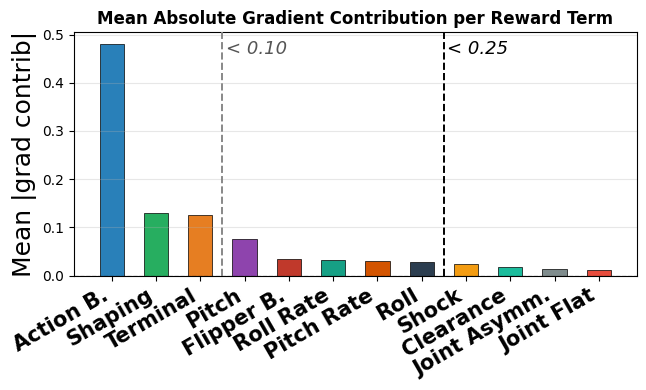

Mean absolute gradient contribution (descending):
  Action B.                           0.4807
  Shaping                             0.1302
  Terminal                            0.1257
  Pitch                               0.0750
  Flipper B.                          0.0350
  Roll Rate                           0.0329
  Pitch Rate                          0.0292
  Roll                                0.0272
  Shock                               0.0230
  Clearance                           0.0168
  Joint Asymm.                        0.0127
  Joint Flat                          0.0116


In [37]:
# ── Mean absolute gradient contribution ──────────────────────────────────────
mean_grad = grad_df.abs().mean()

fig, ax = plot_bar(
    mean_grad,
    title="Mean Absolute Gradient Contribution per Reward Term",
    ylabel="Mean |grad contrib|",
)

# ── Threshold lines ───────────────────────────────────────────────────────────
_sorted_params = list(mean_grad.sort_values(ascending=False).index)
THRESHOLD_LINES = [
    ("Shock",   "black",   "< 0.25", "black"),
    ("Pitch",   "#888888", "< 0.10", "#555555"),
]
for term, lcolor, label, tcolor in THRESHOLD_LINES:
    if term in _sorted_params:
        xi = _sorted_params.index(term) - 0.5
        ax.axvline(xi, color=lcolor, linewidth=1.4, linestyle="--", zorder=5)
        ax.text(xi + 0.07, ax.get_ylim()[1] * 0.97, label,
                color=tcolor, fontsize=13, va="top", fontstyle="italic")

plt.savefig(fname="images/grad_contrib.svg", format="svg")
plt.show()

print("Mean absolute gradient contribution (descending):")
for name, val in mean_grad.sort_values(ascending=False).items():
    print(f"  {name:35s} {val:.4f}")

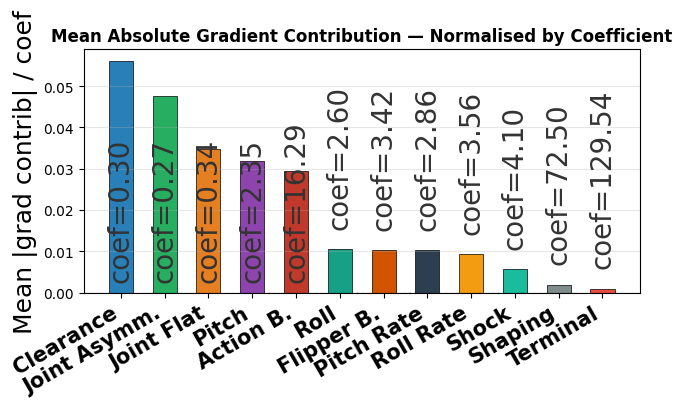

Normalised mean absolute gradient contribution (descending):
  Clearance                  norm=0.05613  (raw=0.0168, coef=0.2997)
  Joint Asymm.               norm=0.04754  (raw=0.0127, coef=0.2675)
  Joint Flat                 norm=0.03468  (raw=0.0116, coef=0.3351)
  Pitch                      norm=0.03190  (raw=0.0750, coef=2.3498)
  Action B.                  norm=0.02951  (raw=0.4807, coef=16.2904)
  Roll                       norm=0.01046  (raw=0.0272, coef=2.5965)
  Flipper B.                 norm=0.01025  (raw=0.0350, coef=3.4183)
  Pitch Rate                 norm=0.01021  (raw=0.0292, coef=2.8642)
  Roll Rate                  norm=0.00923  (raw=0.0329, coef=3.5605)
  Shock                      norm=0.00561  (raw=0.0230, coef=4.0978)
  Shaping                    norm=0.00180  (raw=0.1302, coef=72.5037)
  Terminal                   norm=0.00097  (raw=0.1257, coef=129.5381)


In [38]:
# ── Mean absolute gradient contribution — normalised by coefficient ───────────
coef_series   = pd.Series(COEF)
mean_grad_norm = (mean_grad / coef_series).dropna()

fig, ax = plot_bar(
    mean_grad_norm,
    title="Mean Absolute Gradient Contribution — Normalised by Coefficient",
    ylabel="Mean |grad contrib| / coef",
)
annotate_coefs(ax, mean_grad_norm.sort_values(ascending=False))
plt.tight_layout()
plt.savefig(fname="images/grad_contrib_norm.svg", format="svg")
plt.show()

print("Normalised mean absolute gradient contribution (descending):")
for name, val in mean_grad_norm.sort_values(ascending=False).items():
    coef_val = COEF.get(name, float("nan"))
    print(f"  {name:25s}  norm={val:.5f}  (raw={mean_grad[name]:.4f}, coef={coef_val:.4f})")

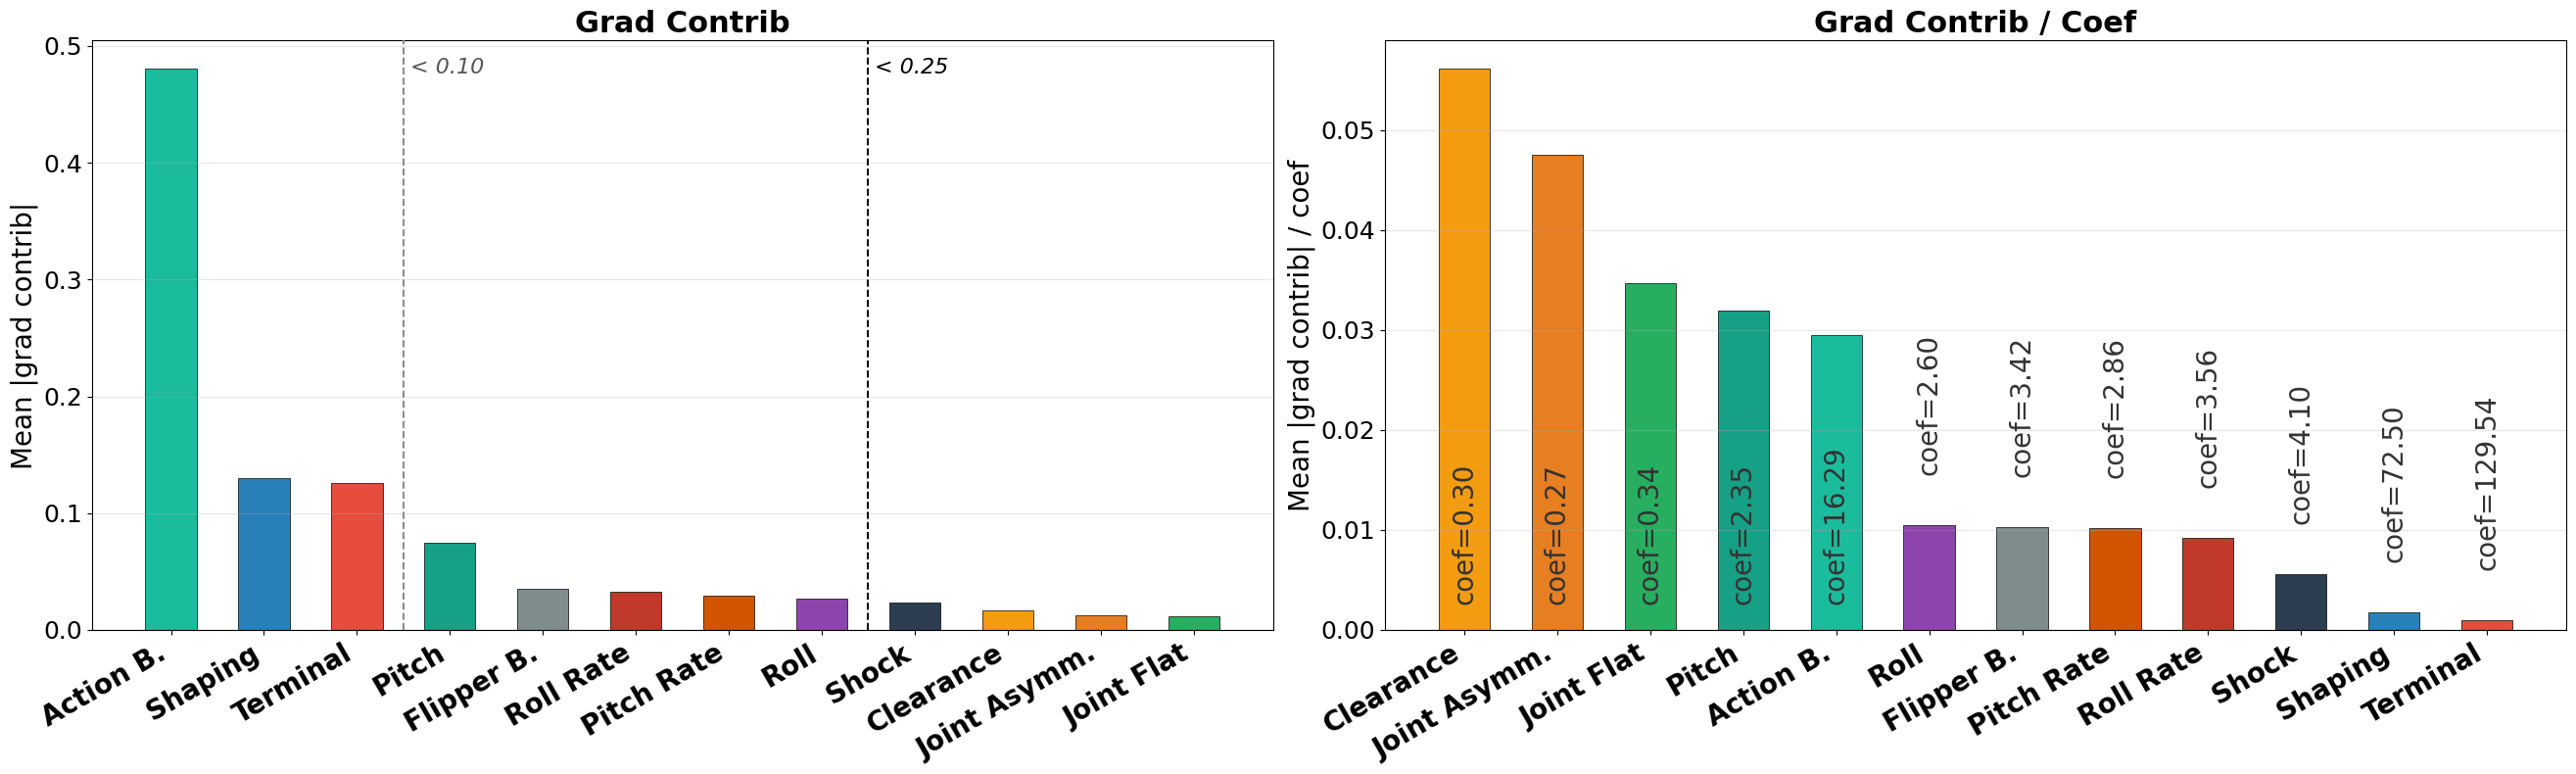

In [39]:
# ── Grad contrib: raw vs normalised side by side ──────────────────────────────
order_grad = mean_grad.sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(max(22, len(order_grad) * 2.2), 8))
plot_bar(mean_grad[order_grad],      "Grad Contrib",
         "Mean |grad contrib|",       ax=axes[0], color_map=TERM_COLORS)
plot_bar(mean_grad_norm[order_grad], "Grad Contrib / Coef",
         "Mean |grad contrib| / coef", ax=axes[1], color_map=TERM_COLORS)
annotate_coefs(axes[1], mean_grad_norm[order_grad])

# Presentation-ready font sizes
for ax in axes:
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=18)
    ax.yaxis.label.set_size(20)
    ax.title.set_size(22)
    ax.title.set_fontweight("bold")

THRESHOLD_LINES = [
    ("Shock",   "black",   "< 0.25", "black"),
    ("Pitch",   "#888888", "< 0.10", "#555555"),
]
for term, lcolor, label, tcolor in THRESHOLD_LINES:
    if term in _sorted_params:
        xi = _sorted_params.index(term) - 0.5
        axes[0].axvline(xi, color=lcolor, linewidth=1.4, linestyle="--", zorder=5)
        axes[0].text(xi + 0.07, axes[0].get_ylim()[1] * 0.97, label,
                     color=tcolor, fontsize=16, va="top", fontstyle="italic")

fig.tight_layout()
plt.savefig(fname="images/grad_contrib_comp.png", format="png", bbox_inches="tight")
plt.show()

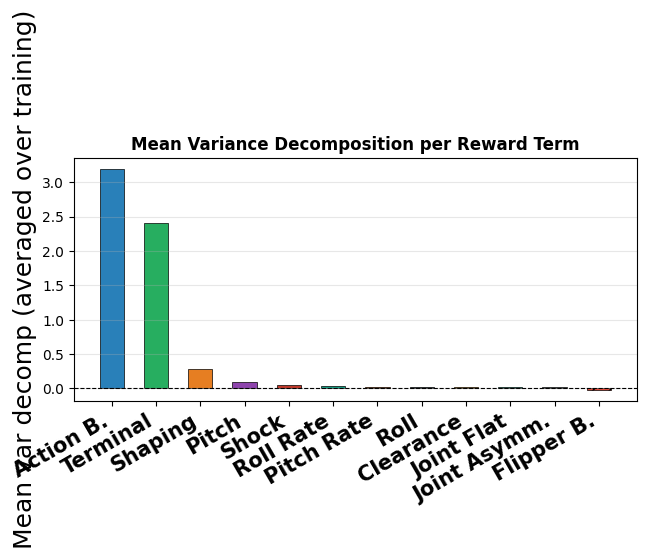

Mean variance decomposition (descending):
  Action B.                           +3.1946
  Terminal                            +2.4086
  Shaping                             +0.2816
  Pitch                               +0.0950
  Shock                               +0.0476
  Roll Rate                           +0.0381
  Pitch Rate                          +0.0246
  Roll                                +0.0222
  Clearance                           +0.0217
  Joint Flat                          +0.0192
  Joint Asymm.                        +0.0167
  Flipper B.                          -0.0217


In [40]:
# ── Mean variance decomposition ───────────────────────────────────────────────
mean_var = var_df.mean()

fig, ax = plot_bar(
    mean_var,
    title="Mean Variance Decomposition per Reward Term",
    ylabel="Mean var decomp (averaged over training)",
)
plt.show()

print("Mean variance decomposition (descending):")
for name, val in mean_var.sort_values(ascending=False).items():
    print(f"  {name:35s} {val:+.4f}")

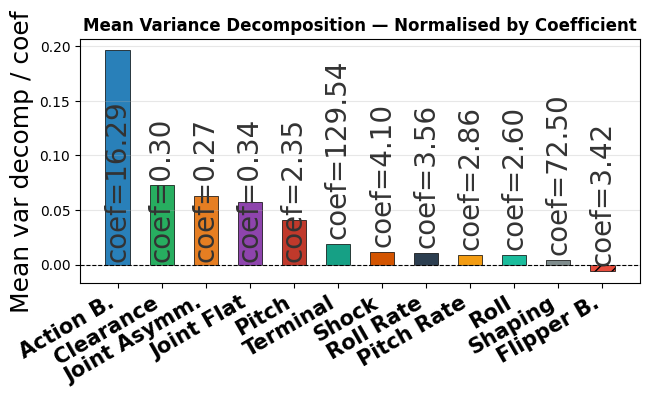

Normalised mean variance decomposition (descending):
  Action B.                  norm=0.19611  (raw=3.1946, coef=16.2904)
  Clearance                  norm=0.07249  (raw=0.0217, coef=0.2997)
  Joint Asymm.               norm=0.06242  (raw=0.0167, coef=0.2675)
  Joint Flat                 norm=0.05718  (raw=0.0192, coef=0.3351)
  Pitch                      norm=0.04043  (raw=0.0950, coef=2.3498)
  Terminal                   norm=0.01859  (raw=2.4086, coef=129.5381)
  Shock                      norm=0.01162  (raw=0.0476, coef=4.0978)
  Roll Rate                  norm=0.01070  (raw=0.0381, coef=3.5605)
  Pitch Rate                 norm=0.00860  (raw=0.0246, coef=2.8642)
  Roll                       norm=0.00855  (raw=0.0222, coef=2.5965)
  Shaping                    norm=0.00388  (raw=0.2816, coef=72.5037)
  Flipper B.                 norm=-0.00633  (raw=-0.0217, coef=3.4183)


In [41]:
# ── Mean variance decomposition — normalised by coefficient ───────────────────
mean_var_norm = (mean_var / coef_series).dropna()

fig, ax = plot_bar(
    mean_var_norm,
    title="Mean Variance Decomposition — Normalised by Coefficient",
    ylabel="Mean var decomp / coef",
)
annotate_coefs(ax, mean_var_norm.sort_values(ascending=False))
plt.tight_layout()
plt.show()

print("Normalised mean variance decomposition (descending):")
for name, val in mean_var_norm.sort_values(ascending=False).items():
    coef_val = COEF.get(name, float("nan"))
    print(f"  {name:25s}  norm={val:.5f}  (raw={mean_var[name]:.4f}, coef={coef_val:.4f})")

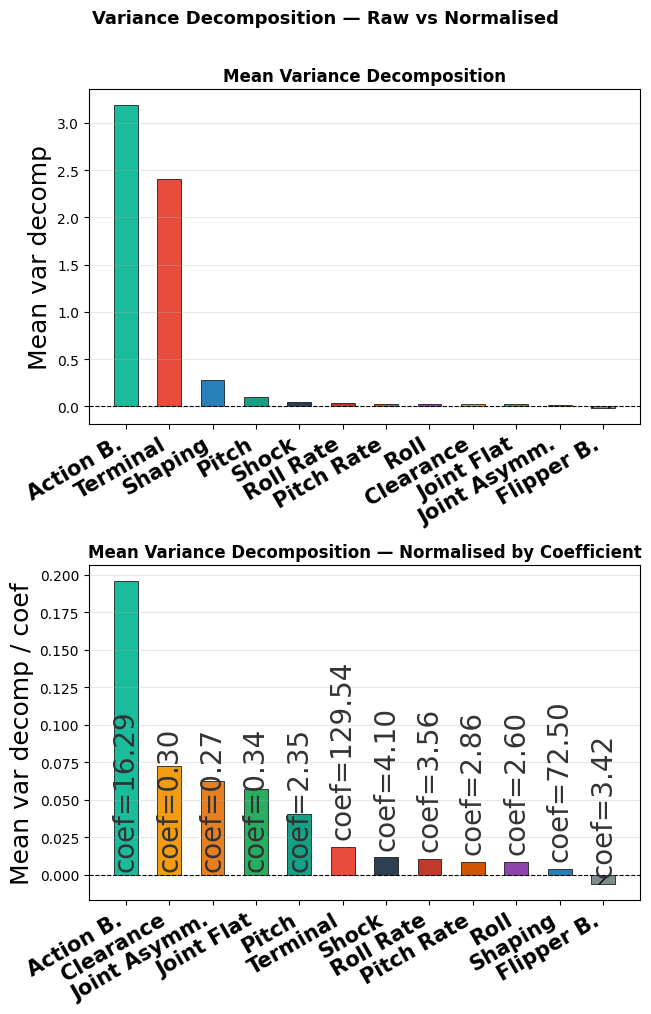

In [42]:
# ── Var decomp: raw vs normalised side by side ────────────────────────────────
order_var = mean_var.sort_values(ascending=False).index

fig, axes = plt.subplots(2, 1, figsize=( len(order_var) * 0.55, 10))
plot_bar(mean_var[order_var],      "Mean Variance Decomposition",
         "Mean var decomp",         ax=axes[0], color_map=TERM_COLORS)
plot_bar(mean_var_norm[order_var], "Mean Variance Decomposition — Normalised by Coefficient",
         "Mean var decomp / coef",  ax=axes[1], color_map=TERM_COLORS)
annotate_coefs(axes[1], mean_var_norm[order_var])

fig.suptitle("Variance Decomposition — Raw vs Normalised",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

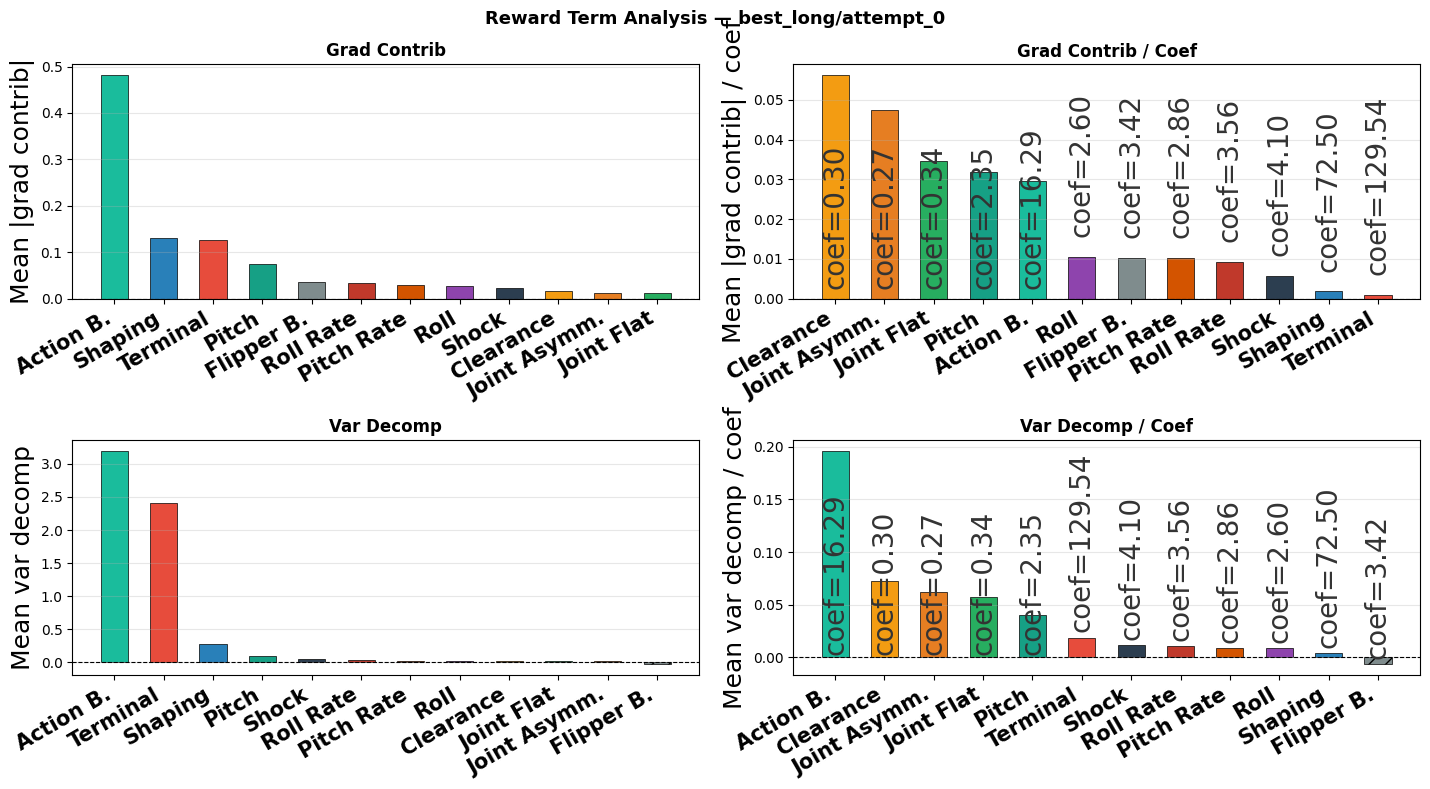

In [43]:
# ── All four side by side ─────────────────────────────────────────────────────
order = mean_grad.sort_values(ascending=False).index

fig, axes = plt.subplots(2, 2, figsize=(len(order) * 1.2, 8))

plot_bar(mean_grad[order],      "Grad Contrib",        "Mean |grad contrib|",       ax=axes[0, 0], color_map=TERM_COLORS)
plot_bar(mean_grad_norm[order], "Grad Contrib / Coef", "Mean |grad contrib| / coef", ax=axes[0, 1], color_map=TERM_COLORS)
plot_bar(mean_var[order],       "Var Decomp",          "Mean var decomp",            ax=axes[1, 0], color_map=TERM_COLORS)
plot_bar(mean_var_norm[order],  "Var Decomp / Coef",   "Mean var decomp / coef",    ax=axes[1, 1], color_map=TERM_COLORS)
annotate_coefs(axes[0, 1], mean_grad_norm[order])
annotate_coefs(axes[1, 1], mean_var_norm[order])

fig.suptitle("Reward Term Analysis — best_long/attempt_0",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(fname="images/rew_comp.svg", format="svg", bbox_inches="tight")
plt.show()

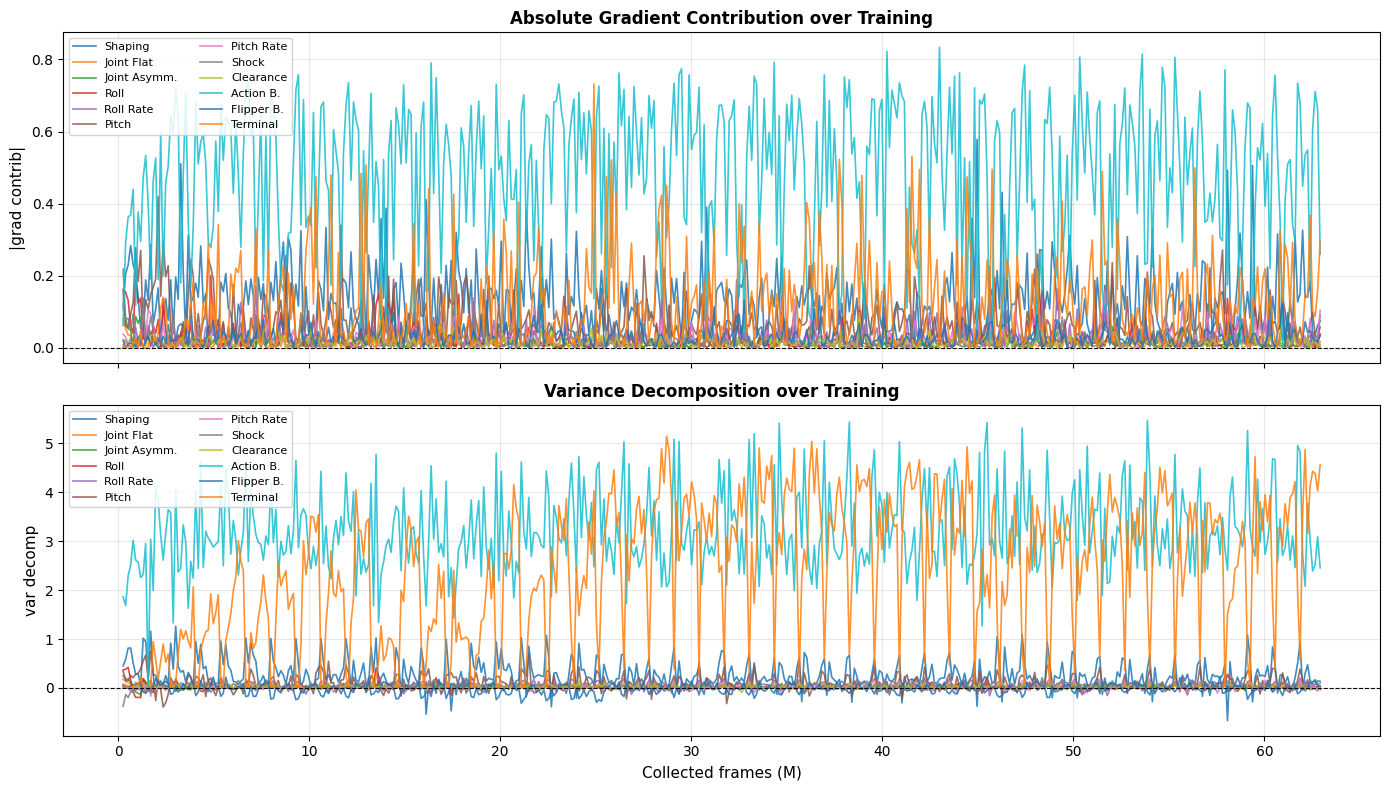

In [44]:
# ── Evolution over training (line chart) ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for col in grad_df.columns:
    axes[0].plot(grad_df.index / 1e6, grad_df[col].abs(), label=col, linewidth=1.2, alpha=0.85)
for col in var_df.columns:
    axes[1].plot(var_df.index  / 1e6, var_df[col],  label=col, linewidth=1.2, alpha=0.85)

for ax, title, ylabel in zip(
    axes,
    ["Absolute Gradient Contribution over Training", "Variance Decomposition over Training"],
    ["|grad contrib|", "var decomp"],
):
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left", ncol=2, framealpha=0.85)

axes[-1].set_xlabel("Collected frames (M)", fontsize=11)
fig.tight_layout()
plt.show()